In [ ]:
import pandas as pd

df2 = pd.read_csv('Dataset.csv')




In [ ]:
df2.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
# for col in ['director', 'country', 'rating', 'listed_in']:
#     df2[col] = df2[col].fillna('Unknown')

features = df2[['director', 'country', 'rating', 'listed_in', 'release_year']]
target = df2['type']

print(features.head())

          director        country rating  \
0  Kirsten Johnson  United States  PG-13   
1  Julien Leclercq         France  TV-MA   
2    Mike Flanagan  United States  TV-MA   
3    Bruno Garotti         Brazil  TV-PG   
4     Haile Gerima  United States  TV-MA   

                                           listed_in  release_year  
0                                      Documentaries          2020  
1  Crime TV Shows, International TV Shows, TV Act...          2021  
2                 TV Dramas, TV Horror, TV Mysteries          2021  
3                 Children & Family Movies, Comedies          2021  
4   Dramas, Independent Movies, International Movies          1993  


In [ ]:
print(target.value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

features_encoded = features.copy()
encoders = {}

for col in ['director', 'country', 'rating', 'listed_in']:
    le = LabelEncoder()
    features_encoded[col] = le.fit_transform(features_encoded[col])
    encoders[col] = le

target_encoded = LabelEncoder().fit_transform(target)  # Movie=0, TV Show=1 (or vice versa)

print(features_encoded.head())

   director  country  rating  listed_in  release_year
0      2294       80       4        273          2020
1      2104       20       8        241          2021
2      2865       80       8        498          2021
3       627        6       9        124          2021
4      1503       80       8        318          1993


In [ ]:
features_encoded.head()

,director,country,rating,listed_in,release_year
0,2294,80,4,273,2020
1,2104,20,8,241,2021
2,2865,80,8,498,2021
3,627,6,9,124,2021
4,1503,80,8,318,1993


In [ ]:
# Explicit encoding instead of LabelEncoder — Movie = 0, TV Show = 1
type_mapping = {'Movie': 0, 'TV Show': 1}
target_encoded = df2['type'].map(type_mapping)

print(target_encoded.value_counts())
print(type_mapping)

type
0    6126
1    2664
Name: count, dtype: int64
{'Movie': 0, 'TV Show': 1}


In [ ]:
target_encoded.head()

,type
0,0
1,1
2,1
3,0
4,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB
None
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


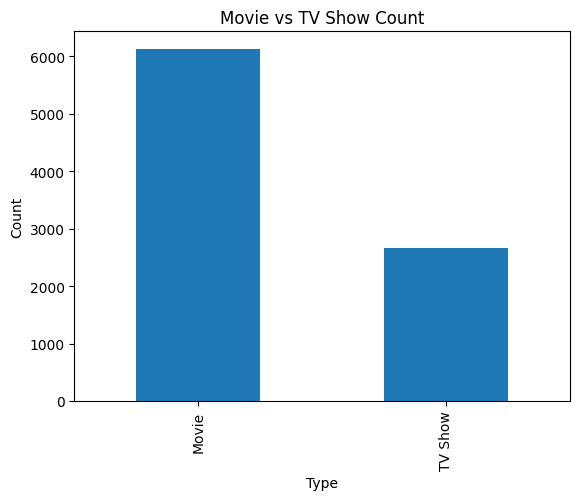

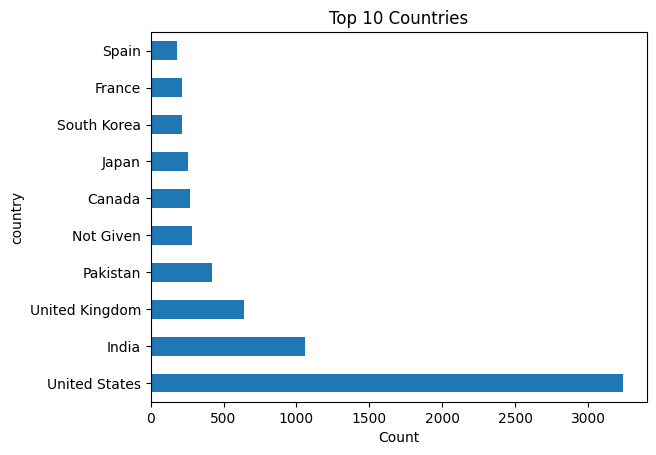

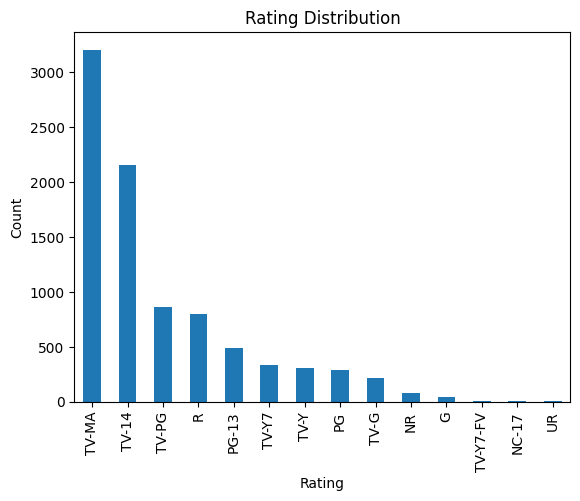

In [ ]:
import matplotlib.pyplot as plt

# Basic info
print(df2.info())
print(df2.isnull().sum())

# Class balance: Movie vs TV Show
df2['type'].value_counts().plot(kind='bar', title='Movie vs TV Show Count')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

# Top 10 countries producing content
df2['country'].value_counts().head(10).plot(kind='barh', title='Top 10 Countries')
plt.xlabel('Count')
plt.show()

# Rating distribution
df2['rating'].value_counts().plot(kind='bar', title='Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

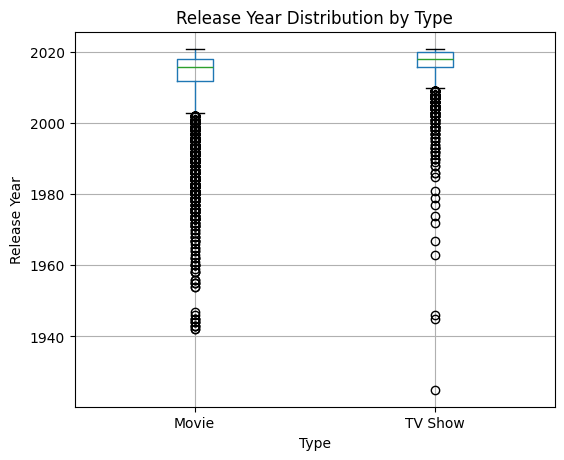

In [ ]:
import matplotlib.pyplot as plt

df2.boxplot(column='release_year', by='type', figsize=(6,5))
plt.title('Release Year Distribution by Type')
plt.suptitle('')  # removes default pandas subtitle
plt.xlabel('Type')
plt.ylabel('Release Year')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target_encoded, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully")

Models trained successfully


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
log_train_acc = accuracy_score(y_train, log_model.predict(X_train))
log_test_acc = accuracy_score(y_test, log_model.predict(X_test))

# Random Forest
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print("Logistic Regression -> Train:", round(log_train_acc, 3), " Test:", round(log_test_acc, 3))
print("Random Forest       -> Train:", round(rf_train_acc, 3), " Test:", round(rf_test_acc, 3))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_model.predict(X_test)))

Logistic Regression -> Train: 0.746  Test: 0.75
Random Forest       -> Train: 1.0  Test: 0.99

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1238
           1       0.99      0.98      0.98       520

    accuracy                           0.99      1758
   macro avg       0.99      0.99      0.99      1758
weighted avg       0.99      0.99      0.99      1758



In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [log_train_acc, rf_train_acc],
    'Test Accuracy': [log_test_acc, rf_test_acc]
})

comparison['Overfit Gap'] = comparison['Train Accuracy'] - comparison['Test Accuracy']

print(comparison)

                 Model  Train Accuracy  Test Accuracy  Overfit Gap
0  Logistic Regression        0.745876       0.749716    -0.003840
1        Random Forest        1.000000       0.989761     0.010239
